# PSet 1 — Problem 3 (Python)

Calibration by simulation: estimate $(\rho, \sigma_u, \sigma_\varepsilon)$ to match moments of $\log y$.

In [1]:
import sys
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from scipy import optimize
from scipy import stats

# Auto-detect hetmacro repo root and add to sys.path
here = Path.cwd()
repo_root = None
for p in [here] + list(here.parents):
    cand = p / 'Heterogeneity In Macroeconomics - Github'
    if cand.exists():
        repo_root = cand
        break
if repo_root is None:
    raise RuntimeError('Could not locate hetmacro repo root')
sys.path.insert(0, str(repo_root))

from hetmacro import optimize as ho

np.set_printoptions(precision=4, suppress=True)

## Model and moments

We simulate:
- $\log \hat z_{t} = \rho \log \hat z_{t-1} + u_t$, $u_t \sim \mathcal{N}(0,\sigma_u^2)$
- $\log z_t = \log \hat z_t + \varepsilon_t$, $\varepsilon_t \sim \mathcal{N}(0,\sigma_\varepsilon^2)$
- Output is proportional to $z$ so correlations/std devs match those of $\log z$ up to a constant.

In [2]:
# Target moments
targets = {
    'std_logy': 1.31,
    'std_dlogy': 0.59,
    'corr_1': 0.90,
    'corr_3': 0.87,
    'corr_5': 0.85,
}

N = 100_000
T = 10

def simulate_logy(rho, su, se, N=N, T=T, seed=0): # Simulate log productivity panel
    rng = np.random.default_rng(seed)
    # initial from ergodic distribution
    sd0 = su / np.sqrt(1.0 - rho**2)
    log_zhat = np.empty((N, T))
    log_zhat[:, 0] = rng.normal(0.0, sd0, size=N)
    u = rng.normal(0.0, su, size=(N, T - 1))
    for t in range(1, T):
        log_zhat[:, t] = rho * log_zhat[:, t - 1] + u[:, t - 1]
    eps = rng.normal(0.0, se, size=(N, T))
    logy = log_zhat + eps
    return logy

def moments_from_logy(logy): # calculate productivity moments
    # std dev of log y
    std_logy = float(np.std(logy))
    dlogy = logy[:, 1:] - logy[:, :-1]
    std_dlogy = float(np.std(dlogy))

    def corr_lag(k):
        a = logy[:, k:].ravel()
        b = logy[:, :-k].ravel()
        return float(np.corrcoef(a, b)[0, 1])

    return {
        'std_logy': std_logy,
        'std_dlogy': std_dlogy,
        'corr_1': corr_lag(1),
        'corr_3': corr_lag(3),
        'corr_5': corr_lag(5),
    }

def sse(theta): # loss function
    rho, su, se = theta
    # simple bounds guard
    if not (0.70 <= rho <= 0.99 and 0.01 <= su <= 0.50 and 0.01 <= se <= 0.50):
        return 1e6
    logy = simulate_logy(rho, su, se, seed=123)
    m = moments_from_logy(logy)
    err = np.array([m[k] - targets[k] for k in targets.keys()])
    return float(err @ err)

def simulate_logy_jump(rho, s_eta, s_eps, pi, mu_J, sigma_J, N=N, T=T, seed=0):
    """Jump-diffusion: x_t = rho*x_{t-1} + eta_t + J_t, J_t = b_t*kappa_t, y_t = x_t + eps_t."""
    rng = np.random.default_rng(seed)
    var_J = pi * (sigma_J**2) + pi * (1 - pi) * (mu_J**2)
    var_x = (s_eta**2 + var_J) / (1.0 - rho**2)
    sd0 = np.sqrt(max(var_x, 1e-12))
    x = np.empty((N, T))
    x[:, 0] = rng.normal(0.0, sd0, size=N)
    for t in range(1, T):
        eta = rng.normal(0.0, s_eta, size=N)
        b = rng.binomial(1, pi, size=N)
        kappa = rng.normal(mu_J, sigma_J, size=N)
        J = b * kappa
        x[:, t] = rho * x[:, t - 1] + eta + J
    eps = rng.normal(0.0, s_eps, size=(N, T))
    logy = x + eps
    return logy

def sse_jump(theta):
    """SSE for jump-diffusion; theta = (rho, s_eta, s_eps, pi, mu_J, sigma_J)."""
    rho, s_eta, s_eps, pi, mu_J, sigma_J = theta
    if not (0.70 <= rho <= 0.99 and 0.01 <= s_eta <= 0.50 and 0.01 <= s_eps <= 0.50 and 0.01 <= pi <= 0.50 and -1.0 <= mu_J <= 1.0 and 0.01 <= sigma_J <= 1.0):
        return 1e6
    logy = simulate_logy_jump(rho, s_eta, s_eps, pi, mu_J, sigma_J, seed=123)
    m = moments_from_logy(logy)
    err = np.array([m[k] - targets[k] for k in targets.keys()])
    return float(err @ err)

## Distribution of changes in log productivity

We visualize the distribution of **changes in log productivity** \(\log z_t\) (persistent component \(\log \hat z_t\) plus transitory \(\varepsilon_t\)) at different horizons:
\begin{align}
    \Delta_1 \log z_t &= \log z_t - \log z_{t-1} \quad \text{(1-year)} \\
    \Delta_3 \log z_t &= \log z_t - \log z_{t-3} \quad \text{(3-year)} \\
    \Delta_5 \log z_t &= \log z_t - \log z_{t-5} \quad \text{(5-year)}
\end{align}
(Output is \(y \propto z\), so the same process describes log income; we refer to **log productivity** as in the model.)


Below we plot the empirical distribution (histogram + KDE) and a normal with the same mean and variance.

1-year Δ log z: mean=0.0001, std=0.3523, kurtosis=3.0071 (normal=3)
3-year Δ log z: mean=0.0001, std=0.4341, kurtosis=3.0018 (normal=3)
5-year Δ log z: mean=0.0001, std=0.4797, kurtosis=3.0045 (normal=3)


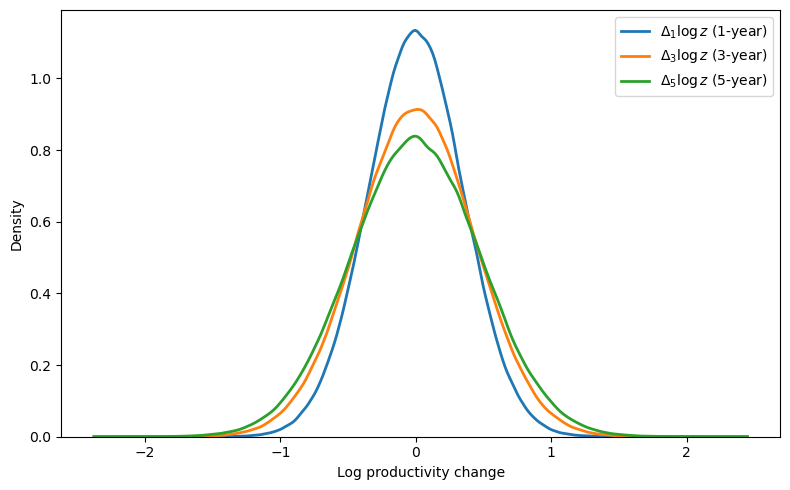

In [3]:
# Simulate with initial/default parameters for illustration
x0 = np.array([0.8, 0.2, 0.2])
logy = simulate_logy(*x0, seed=42) 

# Changes in log productivity (log z) at horizons 1, 3, 5 years
dlogy_1 = (logy[:, 1:] - logy[:, :-1]).ravel()   # 1-year
dlogy_3 = (logy[:, 3:] - logy[:, :-3]).ravel()   # 3-year
dlogy_5 = (logy[:, 5:] - logy[:, :-5]).ravel()  # 5-year

for label, d in [('1-year', dlogy_1), ('3-year', dlogy_3), ('5-year', dlogy_5)]:
    kurt = float(stats.kurtosis(d, fisher=False))
    print(f'{label} Δ log z: mean={d.mean():.4f}, std={d.std():.4f}, kurtosis={kurt:.4f} (normal=3)')

# Single figure: density (y) vs log productivity change (x), all three horizons overlaid
x_min = min(dlogy_1.min(), dlogy_3.min(), dlogy_5.min())
x_max = max(dlogy_1.max(), dlogy_3.max(), dlogy_5.max())
xs = np.linspace(x_min, x_max, 300)

fig, ax = plt.subplots(figsize=(8, 5))
for k, dlogy, label, color in [
    (1, dlogy_1, r'$\Delta_1 \log z$ (1-year)', 'C0'),
    (3, dlogy_3, r'$\Delta_3 \log z$ (3-year)', 'C1'),
    (5, dlogy_5, r'$\Delta_5 \log z$ (5-year)', 'C2'),
]:
    kde = stats.gaussian_kde(dlogy)
    ax.plot(xs, kde(xs), color=color, lw=2, label=label)
ax.set_xlabel('Log productivity change')
ax.set_ylabel('Density')
ax.legend(loc='upper right')
ax.set_ylim(0, None)
plt.tight_layout()
plt.show()

## Estimate parameters

We minimize the sum of squared moment errors (SSE).

In [18]:
x0 = np.array([0.8, 0.2, 0.2])
bounds = [(0.70, 0.99), (0.01, 0.50), (0.01, 0.50)]

res = optimize.minimize(
    sse,
    x0=x0,
    method='Powell',
    bounds=bounds,
    options={'maxiter': 50, 'disp': True},
)
theta_hat = res.x
print('theta_hat =', theta_hat)
print('SSE =', res.fun)

m_hat = moments_from_logy(simulate_logy(*theta_hat, seed=123))
print('--- moments (target vs model) ---')
for k in targets.keys():
    print(f"{k:10s}: target={targets[k]:6.3f}  model={m_hat[k]:6.3f}")

Optimization terminated successfully.
         Current function value: 0.000012
         Iterations: 9
         Function evaluations: 358
theta_hat = [0.9858 0.2103 0.39  ]
SSE = 1.1839947815630383e-05
--- moments (target vs model) ---
std_logy  : target= 1.310  model= 1.310
std_dlogy : target= 0.590  model= 0.590
corr_1    : target= 0.900  model= 0.899
corr_3    : target= 0.870  model= 0.873
corr_5    : target= 0.850  model= 0.849


## Estimate with Nelder-Mead (simplex)

We repeat the same moment-matching estimation using the **simplex-based** Nelder-Mead method from `hetmacro` (analogous to MATLAB's `fminsearch`). The package's `ho.nelder_mead` supports `return_info=True` so we can record and plot the **SSE (error) at each iteration**.

Optimization terminated successfully.
         Current function value: 0.000012
         Iterations: 226
         Function evaluations: 407
theta_hat (Nelder-Mead) = [0.9858 0.2103 0.39  ]
SSE = 1.1839443344361104e-05


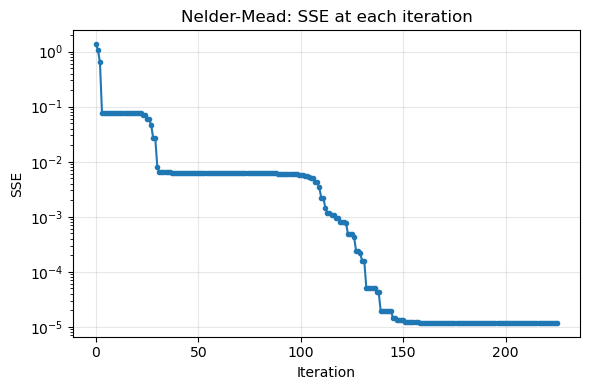

--- moments (target vs model, Nelder-Mead) ---
std_logy  : target= 1.310  model= 1.310
std_dlogy : target= 0.590  model= 0.590
corr_1    : target= 0.900  model= 0.899
corr_3    : target= 0.870  model= 0.873
corr_5    : target= 0.850  model= 0.849


In [4]:
x0_nm = np.array([0.8, 0.2, 0.2])
theta_nm, sse_nm, hist_nm = ho.nelder_mead(
    sse,
    x0_nm,
    tol=1e-8,
    return_info=True,
    options={'maxiter': 2000, 'disp': True},
)
print('theta_hat (Nelder-Mead) =', theta_nm)
print('SSE =', sse_nm)

# Plot SSE at each iteration (error trace)
fig, ax = plt.subplots(figsize=(6, 4))
ax.semilogy(hist_nm['f'], 'o-', markersize=3)
ax.set_xlabel('Iteration')
ax.set_ylabel('SSE')
ax.set_title('Nelder-Mead: SSE at each iteration')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

m_nm = moments_from_logy(simulate_logy(*theta_nm, seed=123))
print('--- moments (target vs model, Nelder-Mead) ---')
for k in targets.keys():
    print(f"{k:10s}: target={targets[k]:6.3f}  model={m_nm[k]:6.3f}")

## Extension: Jump-diffusion (fat tails)

We extend the persistent component to a **jump-diffusion**: $x_t = \rho x_{t-1} + \eta_t + J_t$ with $J_t = b_t \kappa_t$, $b_t \sim \text{Bernoulli}(\pi)$, $\kappa_t \sim \mathcal{N}(\mu_J,\sigma_J^2)$. The same five moments are matched via simulation; the jump component can generate **fat tails** (leptokurtosis) in $\Delta y$. We estimate $\theta = (\rho, \sigma_\eta, \sigma_\varepsilon, \pi, \mu_J, \sigma_J)$ with Nelder-Mead.

Optimization terminated successfully.
         Current function value: 0.000015
         Iterations: 802
         Function evaluations: 1338
theta_jump = [0.9859 0.1976 0.39   0.0501 0.0001 0.3148]
SSE (jump) = 1.5160323785957178e-05


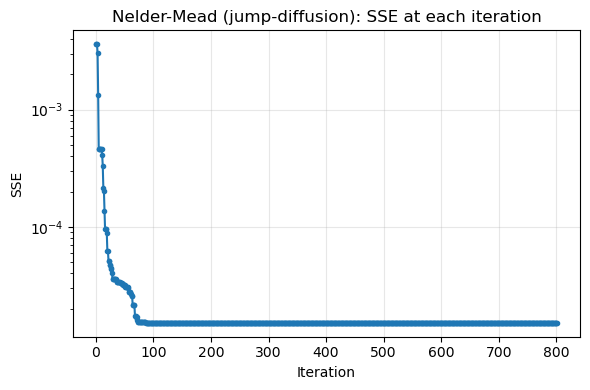

--- moments (target vs model, jump-diffusion) ---
std_logy  : target= 1.310  model= 1.310
std_dlogy : target= 0.590  model= 0.590
corr_1    : target= 0.900  model= 0.899
corr_3    : target= 0.870  model= 0.873
corr_5    : target= 0.850  model= 0.848
Jump 1-year Δ log z: kurtosis=3.0117 (normal=3)
Jump 3-year Δ log z: kurtosis=3.0343 (normal=3)
Jump 5-year Δ log z: kurtosis=3.0294 (normal=3)


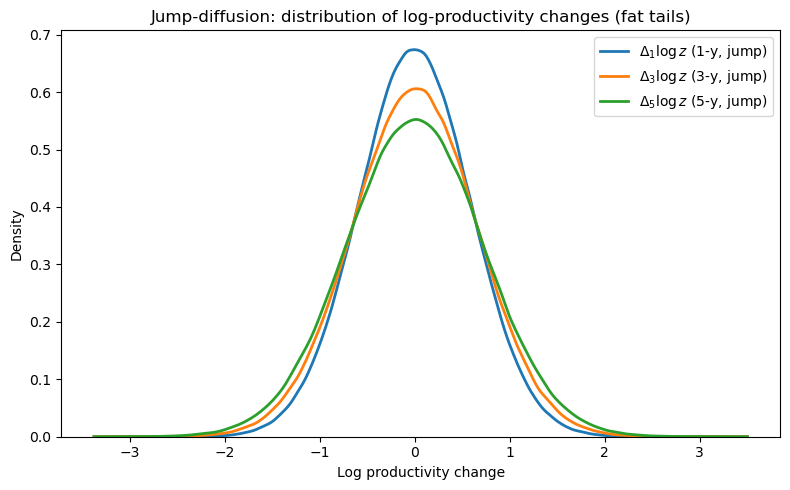

In [5]:
# Initial guess: baseline (rho, s_eta, s_eps) + small jump (pi, mu_J, sigma_J)
x0_jump = np.array([theta_nm[0], theta_nm[1], theta_nm[2], 0.05, 0.0, 0.3])
theta_jump, sse_jump_val, hist_jump = ho.nelder_mead(
    sse_jump,
    x0_jump,
    tol=1e-8,
    return_info=True,
    options={'maxiter': 2000, 'disp': True},
)
print('theta_jump =', theta_jump)
print('SSE (jump) =', sse_jump_val)

# SSE trace for jump-diffusion
fig, ax = plt.subplots(figsize=(6, 4))
ax.semilogy(hist_jump['f'], 'o-', markersize=3)
ax.set_xlabel('Iteration')
ax.set_ylabel('SSE')
ax.set_title('Nelder-Mead (jump-diffusion): SSE at each iteration')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Moments from jump-diffusion fit
m_jump = moments_from_logy(simulate_logy_jump(*theta_jump, seed=123))
print('--- moments (target vs model, jump-diffusion) ---')
for k in targets.keys():
    print(f"{k:10s}: target={targets[k]:6.3f}  model={m_jump[k]:6.3f}")

# Distribution of changes (jump-diffusion): fat tails
logy_jump = simulate_logy_jump(*theta_jump, seed=42)
dlogy_j1 = (logy_jump[:, 1:] - logy_jump[:, :-1]).ravel()
dlogy_j3 = (logy_jump[:, 3:] - logy_jump[:, :-3]).ravel()
dlogy_j5 = (logy_jump[:, 5:] - logy_jump[:, :-5]).ravel()
for label, d in [('1-year', dlogy_j1), ('3-year', dlogy_j3), ('5-year', dlogy_j5)]:
    kurt = float(stats.kurtosis(d, fisher=False))
    print(f'Jump {label} \u0394 log z: kurtosis={kurt:.4f} (normal=3)')
x_min_j = min(dlogy_j1.min(), dlogy_j3.min(), dlogy_j5.min())
x_max_j = max(dlogy_j1.max(), dlogy_j3.max(), dlogy_j5.max())
xs_j = np.linspace(x_min_j, x_max_j, 300)
fig, ax = plt.subplots(figsize=(8, 5))
for dlogy, label, color in [(dlogy_j1, r'$\Delta_1 \log z$ (1-y, jump)', 'C0'), (dlogy_j3, r'$\Delta_3 \log z$ (3-y, jump)', 'C1'), (dlogy_j5, r'$\Delta_5 \log z$ (5-y, jump)', 'C2')]:
    kde = stats.gaussian_kde(dlogy)
    ax.plot(xs_j, kde(xs_j), color=color, lw=2, label=label)
ax.set_xlabel('Log productivity change')
ax.set_ylabel('Density')
ax.set_title('Jump-diffusion: distribution of log-productivity changes (fat tails)')
ax.legend(loc='upper right')
ax.set_ylim(0, None)
plt.tight_layout()
plt.show()

In [ ]:
# Summary tables: target vs model moments (both models) and calibrated parameters
m_nm = moments_from_logy(simulate_logy(*theta_nm, seed=123))

print("=" * 70)
print("Table 1: Target vs model moments")
print("=" * 70)
print(f"{'Moment':<25} {'Target':>10} {'Baseline':>12} {'Jump-diff':>12}")
print("-" * 70)
for k in targets.keys():
    print(f"{k:<25} {targets[k]:>10.3f} {m_nm[k]:>12.3f} {m_jump[k]:>12.3f}")
print()

print("=" * 70)
print("Table 2: Calibrated parameters")
print("=" * 70)
print("Baseline (AR(1)+noise):")
print(f"  rho = {theta_nm[0]:.4f},  sigma_u = {theta_nm[1]:.4f},  sigma_eps = {theta_nm[2]:.4f}")
print("Jump-diffusion:")
print(f"  rho = {theta_jump[0]:.4f},  sigma_eta = {theta_jump[1]:.4f},  sigma_eps = {theta_jump[2]:.4f}")
print(f"  pi = {theta_jump[3]:.4f},  mu_J = {theta_jump[4]:.4f},  sigma_J = {theta_jump[5]:.4f}")